In [2]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(11610, 8) (5160, 8) (3870, 8)


In [4]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [6]:
def train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs,
	clip_grad=False
	):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			if clip_grad:
				nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

In [ ]:
learning_rate = 0.1
n_epochs=30

model = nn.Sequential(
	nn.Linear(8, 30),
	nn.LeakyReLU(),
	nn.BatchNorm1d(30),
	nn.Linear(30, 50),
	nn.LeakyReLU(),
	nn.BatchNorm1d(50),
	nn.Linear(50, 1),
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs)
plot_history(history, n_epochs, metric)

In [12]:
X = np.random.standard_normal((32,8)).round(3)

array([[-0.31 ,  2.227, -1.066,  1.301,  0.104,  0.863,  0.421, -0.357],
       [ 2.212,  2.077,  0.454, -1.362,  1.502, -1.522,  0.097, -1.139],
       [-0.322,  1.357,  0.797,  0.076, -1.35 ,  0.572,  0.404,  1.934],
       [-2.139, -0.689, -0.046, -2.569, -0.681,  1.139, -0.288,  1.12 ],
       [-0.145, -0.643,  1.352,  0.415,  2.22 , -1.357,  0.101, -1.303],
       [ 1.429, -0.094,  0.794,  2.029, -1.163, -1.367,  0.225,  1.251],
       [ 0.709,  0.049, -1.7  , -2.061,  0.329, -1.242,  1.772,  0.385],
       [-2.111, -1.804,  0.376,  0.341,  0.939,  1.173, -0.204,  0.497],
       [-0.023, -0.552,  0.632, -0.078, -0.514,  2.803,  0.092,  0.435],
       [-1.111, -2.546, -1.265, -1.389, -1.375,  1.286,  0.454,  0.385],
       [-0.493,  1.434,  0.782, -0.805,  0.358, -0.611, -2.165,  0.02 ],
       [ 0.306, -0.217,  0.244,  0.423, -1.247,  1.193,  0.415,  1.415],
       [ 0.785,  1.232,  0.106,  0.37 , -0.541, -0.786,  1.173,  1.717],
       [ 0.463, -1.694,  0.873, -0.619,  0.322, -0.

In [16]:
Y = np.random.standard_normal((32,30)).round(3)
Y

array([[-0.437, -0.213,  1.422,  0.619,  0.237,  0.863,  0.983, -0.297,
        -0.748, -0.845,  0.819,  0.855, -0.539, -0.289, -1.471, -0.593,
        -0.214,  0.69 ,  1.136,  0.131, -2.541, -0.982,  0.136, -0.394,
         0.213,  0.15 , -0.522,  1.295, -0.453,  1.014],
       [-2.594, -0.104,  0.588, -0.171,  0.884,  0.794, -2.538,  0.443,
        -0.254,  0.735,  0.031, -0.41 ,  0.766,  2.149, -0.618, -1.016,
         0.92 ,  1.305, -0.29 , -1.115, -1.396,  0.548, -1.06 , -0.391,
         0.006, -0.503, -1.106,  0.243,  0.389,  0.39 ],
       [ 1.321, -0.02 ,  1.035,  0.463, -1.781, -2.504, -1.624,  0.96 ,
         0.367, -1.099,  0.361, -1.112,  1.187,  0.23 , -0.557, -0.973,
         1.267, -0.839, -2.868,  0.538,  1.582,  0.537,  0.649, -1.583,
        -1.114,  0.046,  0.528,  0.009,  0.216,  1.038],
       [ 0.216, -0.559, -0.028, -1.303,  0.534, -0.097, -0.848, -0.219,
        -0.23 ,  1.188, -0.393, -0.541, -1.209,  0.189,  0.359,  0.685,
        -0.286, -0.801, -1.561, -0.34

In [30]:
M = Y.mean(axis=0)
S = Y.std(axis=0)
# M.shape

In [36]:
((Y-M)/S).round(2)

array([[-0.49,  0.01,  1.  ,  0.5 ,  0.24,  0.78,  0.91, -0.04, -0.77,
        -0.65,  0.5 ,  1.15, -0.53, -0.64, -1.24, -0.52, -0.39,  0.78,
         0.99,  0.46, -2.09, -0.96,  0.38, -0.31,  0.19,  0.22, -0.57,
         1.23, -0.62,  0.96],
       [-2.62,  0.16,  0.25, -0.37,  0.79,  0.72, -2.44,  0.8 , -0.29,
         1.13, -0.19, -0.29,  0.8 ,  1.82, -0.34, -0.87,  0.97,  1.37,
        -0.28, -0.82, -1.16,  0.83, -1.38, -0.31, -0.06, -0.35, -1.22,
         0.21,  0.28,  0.44],
       [ 1.25,  0.28,  0.65,  0.33, -1.49, -2.08, -1.57,  1.38,  0.33,
        -0.93,  0.1 , -1.1 ,  1.22, -0.12, -0.27, -0.84,  1.39, -0.68,
        -2.58,  0.87,  1.27,  0.82,  1.13, -1.64, -1.4 ,  0.13,  0.6 ,
        -0.02,  0.1 ,  0.98],
       [ 0.16, -0.48, -0.31, -1.61,  0.49, -0.04, -0.83,  0.05, -0.26,
         1.64, -0.56, -0.44, -1.21, -0.16,  0.69,  0.55, -0.48, -0.64,
        -1.41, -0.03, -1.87,  1.85,  0.09,  0.79,  0.15, -0.1 , -0.4 ,
         1.08, -0.5 , -1.45],
       [ 0.03, -0.52,  2.38,

In [37]:
30*0.2

6.0

Epoch: 1/30, Loss: 0.653, Train Metric: 0.565, Valid Metric: 0.516
Epoch: 2/30, Loss: 0.466, Train Metric: 0.483, Valid Metric: 0.465
Epoch: 3/30, Loss: 0.436, Train Metric: 0.464, Valid Metric: 0.459
Epoch: 4/30, Loss: 0.403, Train Metric: 0.449, Valid Metric: 0.429
Epoch: 5/30, Loss: 0.396, Train Metric: 0.444, Valid Metric: 0.429
Epoch: 6/30, Loss: 0.378, Train Metric: 0.436, Valid Metric: 0.405
Epoch: 7/30, Loss: 0.374, Train Metric: 0.432, Valid Metric: 0.51
Epoch: 8/30, Loss: 0.37, Train Metric: 0.425, Valid Metric: 0.416
Epoch: 9/30, Loss: 0.363, Train Metric: 0.423, Valid Metric: 0.394
Epoch: 10/30, Loss: 0.35, Train Metric: 0.418, Valid Metric: 0.406
Epoch: 11/30, Loss: 0.349, Train Metric: 0.415, Valid Metric: 0.403
Epoch: 12/30, Loss: 0.35, Train Metric: 0.414, Valid Metric: 0.417
Epoch: 13/30, Loss: 0.342, Train Metric: 0.411, Valid Metric: 0.389
Epoch: 14/30, Loss: 0.339, Train Metric: 0.41, Valid Metric: 0.412
Epoch: 15/30, Loss: 0.34, Train Metric: 0.409, Valid Metric: 0

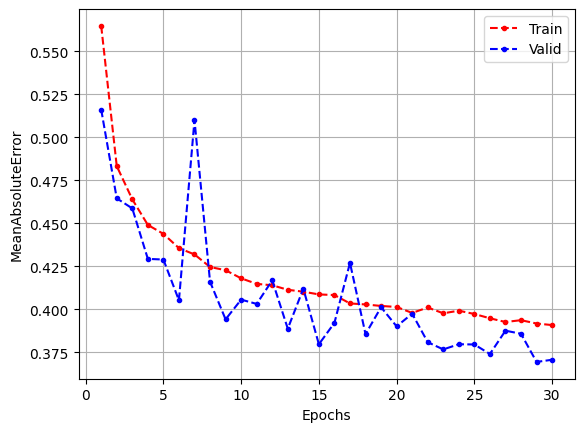

In [39]:
learning_rate = 0.1
n_epochs=30

model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Dropout(0.2),
	nn.Linear(in_features=50, out_features=1),
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs,
	clip_grad=True
	)
plot_history(history, n_epochs, metric)

In [47]:
isinstance(module, nn.Dropout)

False

In [53]:
model.eval()
for i, module in enumerate(model.modules()):
    if isinstance(module, nn.Dropout):
        module.train()

X_new, y_new = test_loader.dataset[:1]

X_new, y_new

(tensor([[-1.1441, -0.3679,  0.1230, -0.1463, -0.2271, -0.0102,  0.2264,  0.2769]]),
 tensor([[0.9550]]))

In [74]:
model(X_new)

tensor([[0.5898]], grad_fn=<AddmmBackward0>)

In [75]:
with torch.no_grad():
	X_new_repeated = X_new.repeat_interleave(100, dim=0)
	y_pred = model(X_new_repeated)

In [77]:
y_pred.mean()

tensor(0.7212)